# All final plots and analyses for figure 1

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import math
warnings.filterwarnings('ignore')
import joblib
import matplotlib.colors as mcolors

## Model performance interpretation: bulk - pseudobulk correlation on marker genes

In [ ]:
# Load model to get most important features
model = joblib.load('../../grood_runs/GrooD_Hao_Finotello/intersect_CPM/train/model/Model.pkl')
model

ValueError: <class 'numpy.random._mt19937.MT19937'> is not a known BitGenerator module.

In [3]:
# Load bulks from Finotello
bulk = pd.read_csv('../../data/bulk_data/Finotello_2019/final_data/Finotello_TPM_data.csv', index_col=0)
bulk

,UBE2Q2P2,SSX9,CXorf67,EFCAB8,SPATA31B1P,SDR16C6P,GTPBP6,EFCAB12,A1BG,A1CF,...,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,TPTEP1
pbmc_1,0.000000,0.000000,0.118865,0.000000,0.0,0.000000,57.280197,0.252188,10.863071,0.000000,...,3.477319,3.44931,6.36162,16.473360,0.426082,7.471390,327.737590,17.070511,14.530079,5.155380
pbmc_10,0.081115,0.000000,0.086782,0.000000,0.0,0.000000,72.275326,0.095742,14.785649,0.000000,...,3.712750,3.55546,5.50518,14.924620,0.222251,6.381709,442.838401,12.744583,9.246122,13.326484
pbmc_12,0.000000,0.000000,0.188464,0.031570,0.0,0.000000,50.997427,0.100608,7.492537,0.000000,...,2.937518,3.70517,7.47136,16.866000,0.409656,9.498991,364.599060,18.526458,13.210396,19.452058
pbmc_2,0.000000,0.000000,0.094006,0.004499,0.0,0.000000,60.604133,0.050183,15.827180,0.000000,...,2.454242,1.86107,3.35811,13.062773,0.405473,5.799880,219.376050,12.623465,5.652651,13.401427
pbmc_4,0.059691,0.212565,0.496705,0.346400,0.0,0.287881,104.405300,0.984864,10.540150,0.269025,...,2.885740,3.78000,9.81738,30.148749,4.520060,12.566580,250.918200,34.720530,12.323414,45.098055
pbmc_5,0.613015,0.000000,0.196090,0.385828,0.0,0.000000,102.156500,0.513702,6.647064,0.000000,...,3.758755,4.24224,10.62830,30.756770,1.147440,11.558017,372.000060,37.414882,13.270457,17.063871
pbmc_6,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,52.882543,0.176120,9.519831,0.000000,...,4.256100,3.51173,4.68182,15.245900,0.213477,7.536230,458.764880,15.674012,9.396960,12.847275
pbmc_7,0.000000,0.000000,0.165406,0.048187,0.0,0.000000,61.837424,0.044789,9.196318,0.000000,...,2.472849,2.89564,5.98077,14.535830,0.520593,5.990022,290.344501,16.399724,10.407555,15.988808
pbmc_9,0.000000,0.000000,0.157926,0.041571,0.0,0.000000,47.350889,0.098357,9.537508,0.000000,...,3.869803,3.45627,5.65227,14.146395,0.508913,7.500722,380.691001,14.024112,8.513980,8.728245


In [4]:
# Create mean bulk
mean_bulk = pd.DataFrame(np.mean(bulk, axis=0), columns = ['bulk'])
mean_bulk

,bulk
UBE2Q2P2,0.083758
SSX9,0.023618
CXorf67,0.167138
EFCAB8,0.095340
SPATA31B1P,0.000000
...,...
ZYG11B,8.255949
ZYX,345.252194
ZZEF1,19.910920
ZZZ3,10.727957


In [5]:
pbs = pd.read_csv('../../grood_runs/GrooD_Hao_Finotello/intersect_CPM/pseudobulk/Pseudobulks.csv', index_col=0)
mean_pb = pd.DataFrame(np.mean(pbs, axis=0), columns=['pb'])
mean_pb

,pb
AL627309.1,2.415
AL627309.3,0.318
AL627309.4,0.382
AL669831.5,82.006
FAM87B,0.777
...,...
AL354822.1,11.556
AC004556.1,26.870
AC233755.2,0.866
AC233755.1,2.889


In [6]:
# Subset to common genes
common_genes = model['model'].estimators_[0].feature_names_in_.tolist()
len(common_genes)

14399

In [7]:
# Subset and combine bulk and pseudobulk
mean_pb = mean_pb.loc[common_genes]
mean_bulk = mean_bulk.loc[common_genes]
means = pd.concat([mean_bulk, mean_pb], axis=1)
means

,bulk,pb
CXorf67,0.167138,0.328
EFCAB8,0.095340,0.246
GTPBP6,67.754415,346.367
EFCAB12,0.257395,1.808
A1BG,10.489923,417.946
...,...,...
ZXDC,18.462266,133.448
ZYG11A,0.930438,1.255
ZYG11B,8.255949,224.224
ZYX,345.252194,962.953


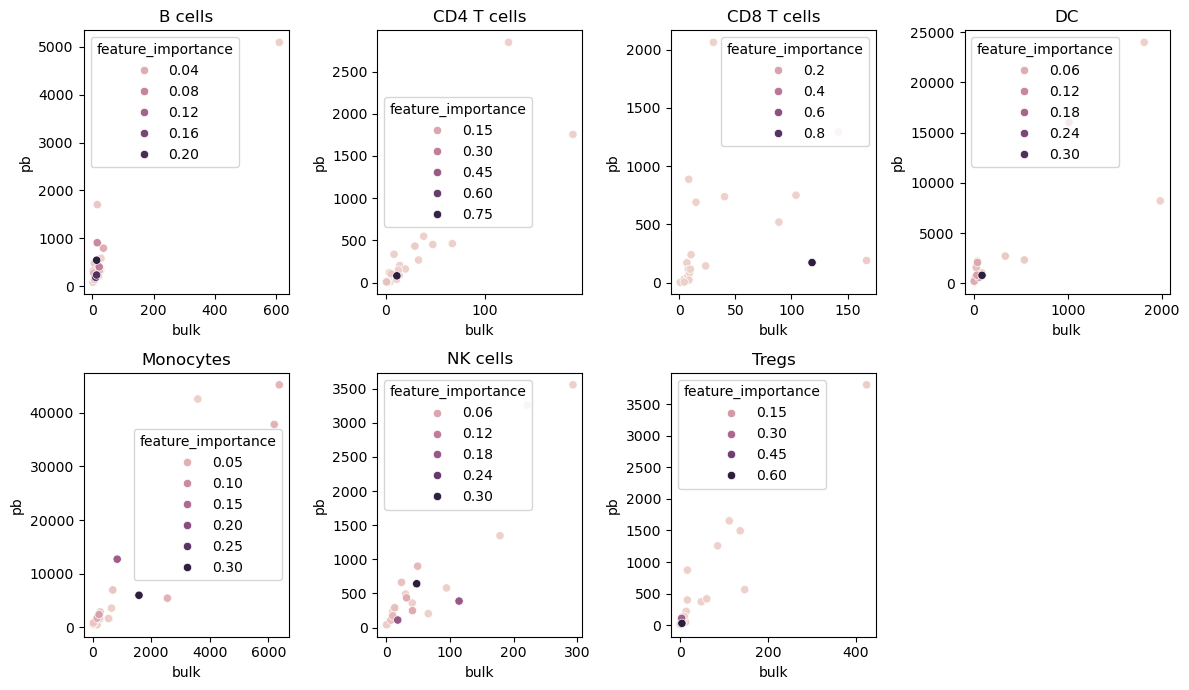

In [8]:
# Plotting feature importances
def plot_marker_expression_correlation(model, estimators, mean_expressions):
    
    # Get list of cellTypes (same order as in model estimators)
    cellTypes = estimators
    genes = model.estimators_[0].feature_names_in_.tolist()

    # Configure subplots
    n = len(cellTypes)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    # iterate over n or cellTypes
    for i in range(0,len(cellTypes)):
        cellType = cellTypes[i]
        feature_importance = model.estimators_[i].feature_importances_
        sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
        most_important_features = sorted_idx[-20:] # get 20 most important features
        marker_genes = np.array(genes)[most_important_features]
        plot_df = mean_expressions.loc[marker_genes]
        plot_df['feature_importance'] = feature_importance[most_important_features]
        pos = np.arange(most_important_features.shape[0]) + 0.5
        sns.scatterplot(plot_df, x='bulk', y='pb', hue='feature_importance', ax=axes[i])
        axes[i].set_title(cellType)

    # Hide any unused axes
    for j in range(len(cellTypes), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    # plt.savefig('Figure_1B.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

estimators = model['metadata']['estimators']
plot_marker_expression_correlation(model['model'], estimators, means)

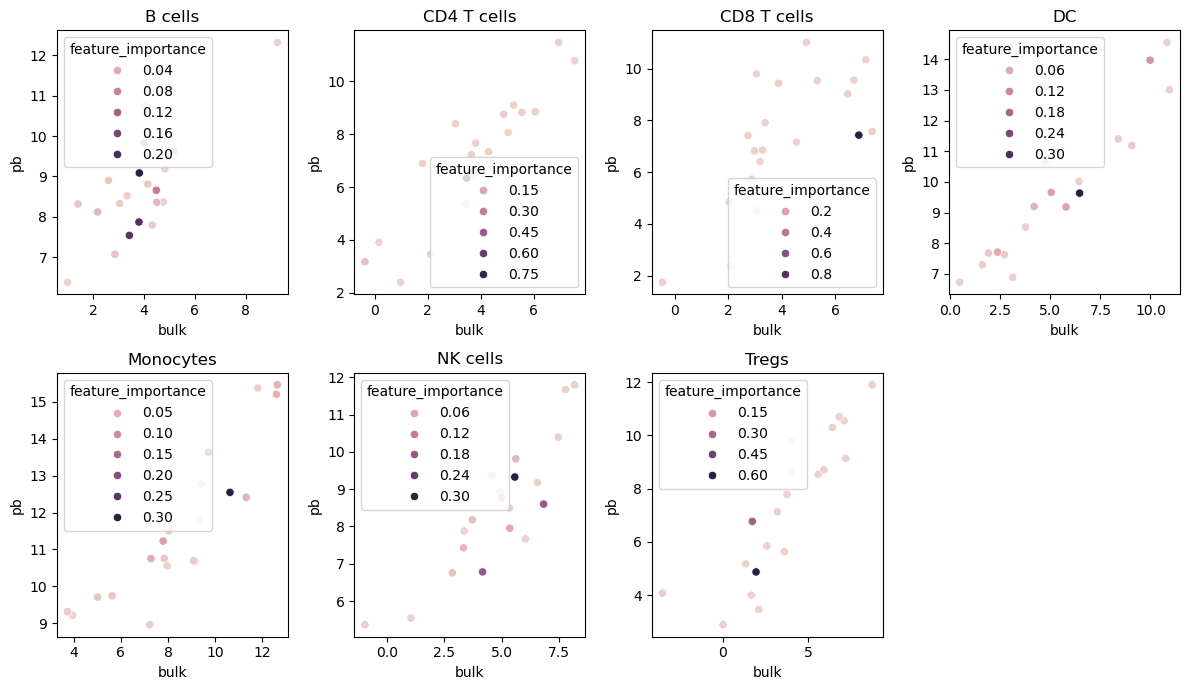

In [9]:
# Same for log2 normalized expression

means_log = pd.DataFrame(np.log2(means), index=means.index.tolist(), columns=means.columns.tolist())
plot_marker_expression_correlation(model['model'], estimators, means_log)

## Plot proportions against expression across samples

In [10]:
pb_props = pd.read_csv('../../grood_runs/GrooD_Hao_Finotello/intersect_CPM/pseudobulk/Pseudobulk_proprotions.csv', index_col=0)
pb_props

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs
Sample_1,0.561245,0.081325,0.013052,0.056225,0.130522,0.138554,0.019076
Sample_2,0.247992,0.192771,0.028112,0.355422,0.149598,0.000000,0.026104
Sample_3,0.011033,0.018054,0.023069,0.255767,0.026078,0.654965,0.011033
Sample_4,0.032096,0.403210,0.017051,0.059178,0.473420,0.000000,0.015045
Sample_5,0.158475,0.231695,0.002006,0.000000,0.149448,0.431294,0.027081
...,...,...,...,...,...,...,...
Sample_996,0.030120,0.104418,0.083333,0.248996,0.209839,0.061245,0.262048
Sample_997,0.071285,0.107430,0.034137,0.301205,0.280120,0.051205,0.154618
Sample_998,0.037186,0.101508,0.016080,0.002010,0.555779,0.160804,0.126633
Sample_999,0.183551,0.018054,0.084253,0.236710,0.064193,0.001003,0.412237


In [11]:
pbs

,AL627309.1,AL627309.3,AL627309.4,AL669831.5,FAM87B,LINC00115,FAM41C,AL645608.3,SAMD11,NOC2L,...,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC233755.2,AC233755.1,AC240274.1
Sample_1,2.0,0.0,0.0,71.0,0.0,37.0,17.0,0.0,0.0,230.0,...,2.0,8.0,6.0,192.0,5.0,8.0,19.0,0.0,8.0,40.0
Sample_2,0.0,0.0,1.0,121.0,2.0,39.0,20.0,0.0,1.0,321.0,...,2.0,8.0,4.0,173.0,9.0,15.0,37.0,1.0,12.0,57.0
Sample_3,0.0,1.0,0.0,88.0,1.0,29.0,18.0,0.0,1.0,316.0,...,0.0,8.0,6.0,140.0,7.0,16.0,24.0,0.0,0.0,42.0
Sample_4,1.0,0.0,1.0,75.0,0.0,36.0,19.0,1.0,2.0,250.0,...,1.0,7.0,4.0,128.0,12.0,11.0,23.0,0.0,0.0,48.0
Sample_5,2.0,0.0,0.0,55.0,0.0,22.0,21.0,0.0,1.0,227.0,...,1.0,7.0,1.0,116.0,5.0,2.0,11.0,0.0,9.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sample_996,1.0,0.0,0.0,89.0,0.0,33.0,14.0,1.0,1.0,322.0,...,1.0,11.0,11.0,133.0,5.0,9.0,31.0,0.0,0.0,41.0
Sample_997,4.0,0.0,1.0,103.0,1.0,36.0,27.0,1.0,2.0,322.0,...,3.0,6.0,6.0,129.0,16.0,10.0,39.0,0.0,1.0,54.0
Sample_998,1.0,1.0,0.0,81.0,0.0,28.0,22.0,0.0,0.0,252.0,...,1.0,3.0,4.0,115.0,15.0,7.0,19.0,0.0,0.0,40.0
Sample_999,0.0,0.0,0.0,72.0,1.0,31.0,11.0,1.0,0.0,250.0,...,2.0,5.0,5.0,154.0,5.0,10.0,26.0,0.0,2.0,38.0


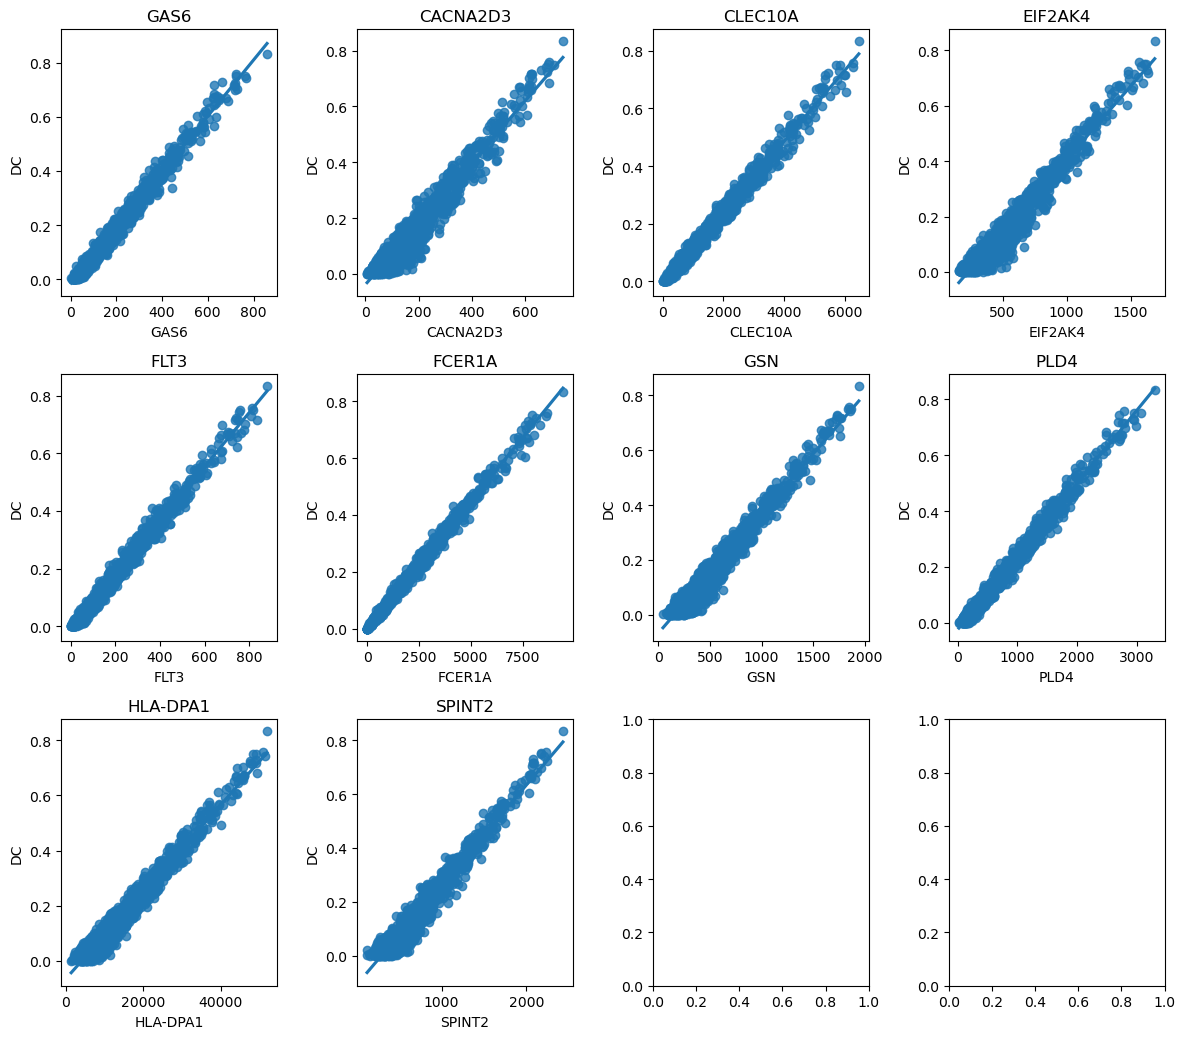

In [20]:
# Plotting feature importances
def plot_marker_prop_expression_correlation(model, cellType, pb, props, estimators):
    
    # Get list of cellTypes (same order as in model estimators)
    genes = model.estimators_[0].feature_names_in_.tolist()

    # Configure subplots
    n = 10
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    cellType_pos = estimators.index(cellType)
    feature_importance = model.estimators_[cellType_pos].feature_importances_
    sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
    most_important_features = sorted_idx[-n:] # get n most important features
    marker_genes = np.array(genes)[most_important_features]

    df_plot = pd.concat([props[cellType], pb[marker_genes]], axis=1)

    # iterate over n or cellTypes
    for i, gene in enumerate(marker_genes):
        plot_df = df_plot[[gene, cellType]]
        sns.regplot(plot_df, x=gene, y=cellType, ax=axes[i])
        axes[i].set_title(gene)

    # # Hide any unused axes
    # for j in range(len(cellTypes), len(axes)):
    #     fig.delaxes(axes[j])

    plt.tight_layout()
    # plt.savefig('Figure_1B.svg', transparent = True, dpi = 300, format = 'svg')
    plt.show()

estimators = model['metadata']['estimators']
plot_marker_prop_expression_correlation(model['model'], 'DC', pbs, pb_props, estimators)

In [22]:
bulk_pred_props = pd.read_csv("../../grood_runs/GrooD_Hao_Finotello/intersect_CPM/inference/Predicted_cell_type_proportions.csv", index_col=0)
bulk_truth_props = pd.read_csv("../../data/bulk_data/Finotello_2019/final_data/Finotello_FACS_proportions_no_neutrophils_others.csv", index_col=0)

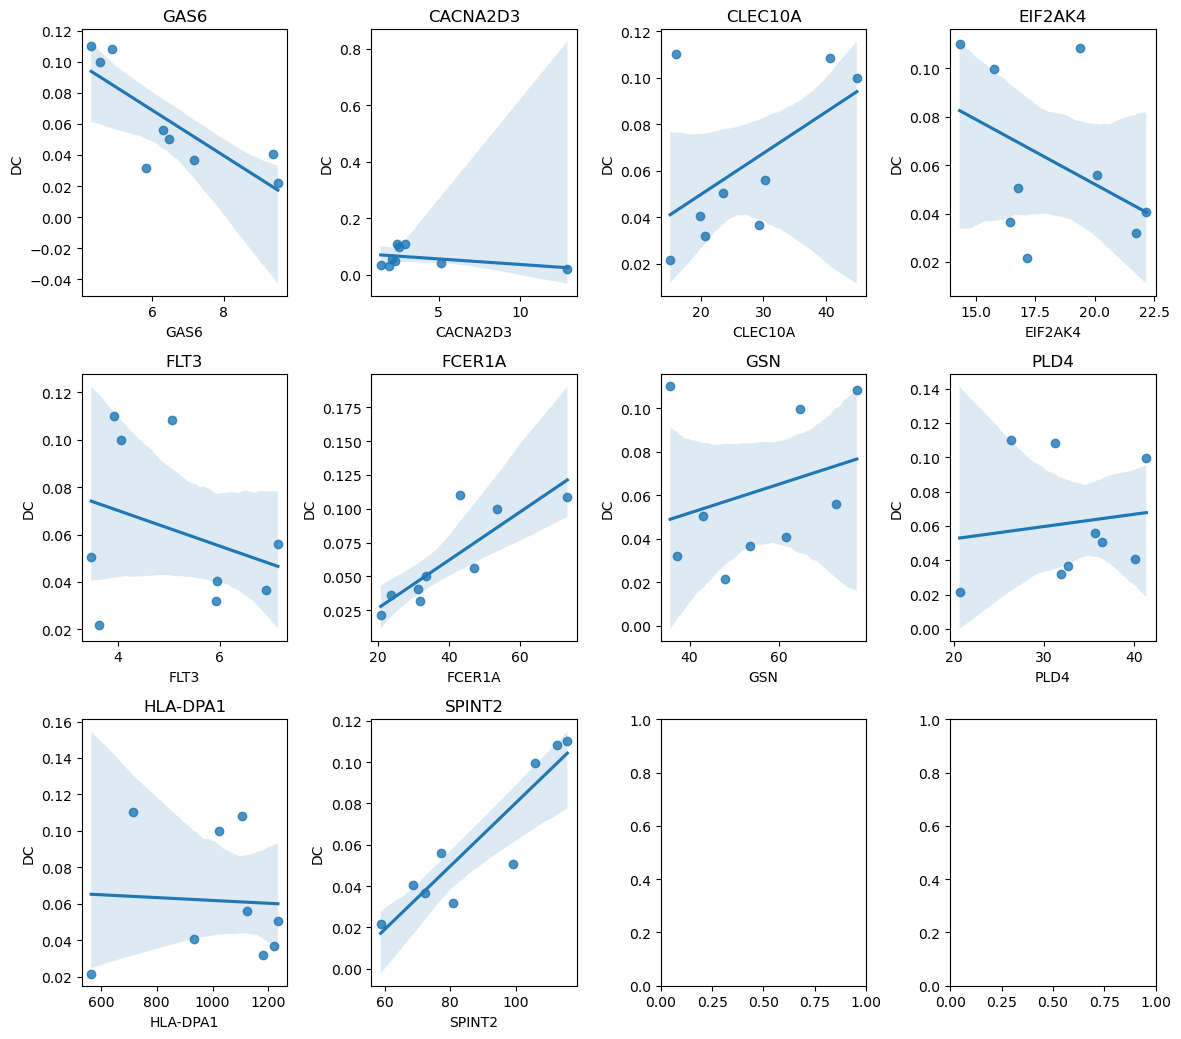

In [21]:
plot_marker_prop_expression_correlation(model['model'], 'DC', bulk, bulk_pred_props, estimators)

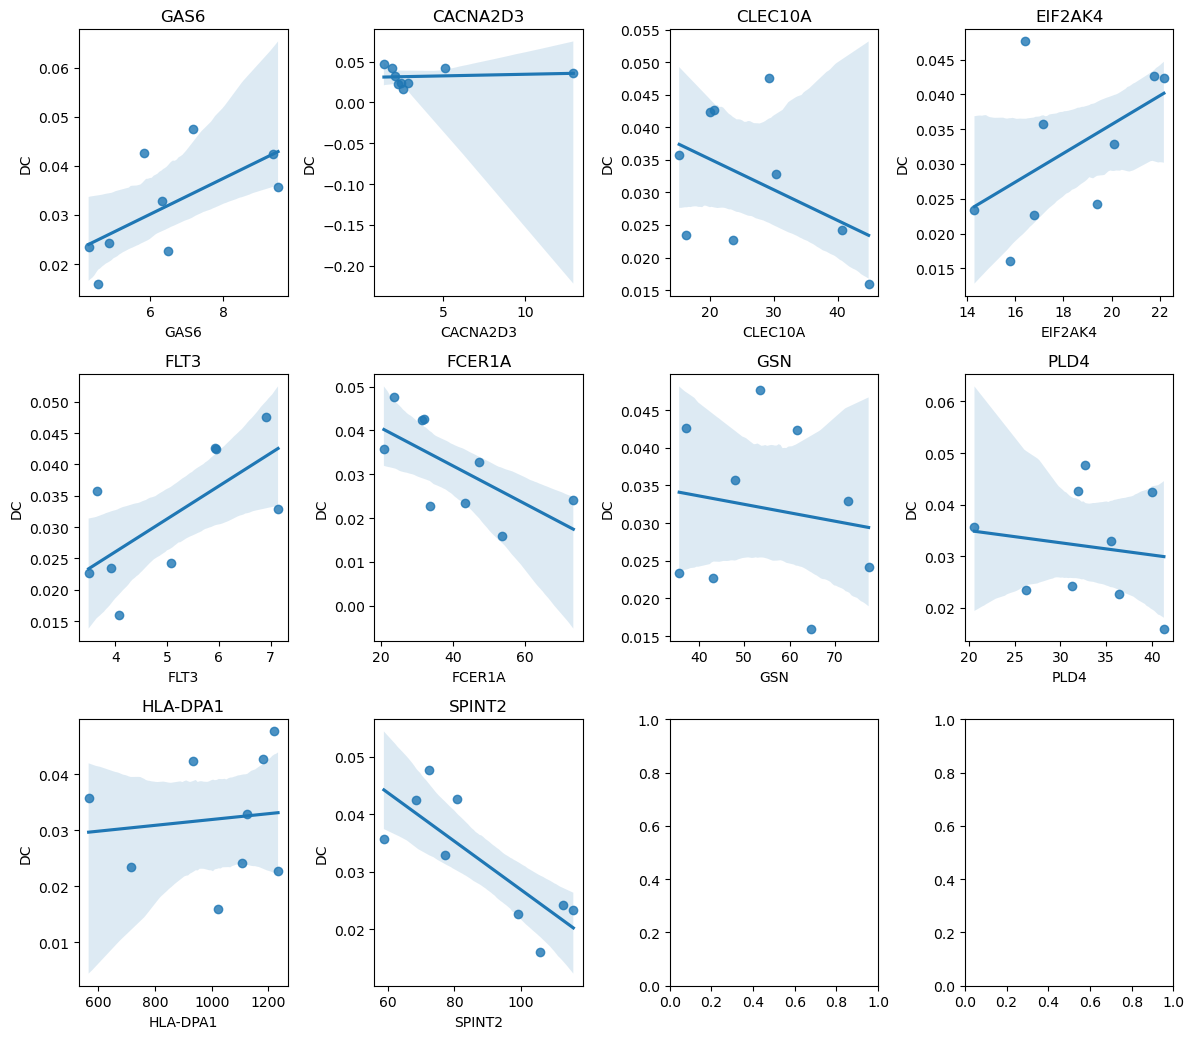

In [23]:
plot_marker_prop_expression_correlation(model['model'], 'DC', bulk, bulk_truth_props, estimators)